In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:


np.random.seed(42)

df = pd.DataFrame({
    "student_id": [f"STU{i:03d}" for i in range(1, 101)],

    "gender": np.random.choice(
        ["Male", "Female", np.nan],
        size=100,
        p=[0.45, 0.45, 0.10]
    ),

    "department": np.random.choice(
        ["CSE", "EEE", "BBA", "English", "ETE", np.nan],
        size=100,
        p=[0.25, 0.20, 0.20, 0.15, 0.10, 0.10]
    ),

    "study_hours": np.round(np.random.normal(4.5, 1.5, 100), 1),

    "attendance_percent": np.round(np.random.normal(75, 12, 100), 1),

    "final_score": np.round(np.random.normal(70, 15, 100), 1)
})

# Add more null values manually
df.loc[[3, 15, 29, 45, 67], "study_hours"] = np.nan
df.loc[[8, 21, 39, 56, 88], "attendance_percent"] = np.nan
df.loc[[5, 18, 33, 72, 91], "final_score"] = np.nan
df.loc[[10, 40, 70], "gender"] = np.nan
df.loc[[12, 50, 82], "department"] = np.nan

df

,student_id,gender,department,study_hours,attendance_percent,final_score
0,STU001,Male,CSE,3.5,100.5,82.9
1,STU002,nan,BBA,4.8,87.4,67.6
2,STU003,Female,EEE,4.9,56.8,69.7
3,STU004,Female,BBA,NaN,69.2,55.0
4,STU005,Male,nan,7.3,90.2,69.7
...,...,...,...,...,...,...
95,STU096,Female,EEE,3.5,58.1,55.9
96,STU097,Female,English,7.1,66.4,62.3
97,STU098,Male,ETE,5.1,72.4,54.1
98,STU099,Male,ETE,2.6,78.7,69.1


In [3]:
df

,student_id,gender,department,study_hours,attendance_percent,final_score
0,STU001,Male,CSE,3.5,100.5,82.9
1,STU002,nan,BBA,4.8,87.4,67.6
2,STU003,Female,EEE,4.9,56.8,69.7
3,STU004,Female,BBA,NaN,69.2,55.0
4,STU005,Male,nan,7.3,90.2,69.7
...,...,...,...,...,...,...
95,STU096,Female,EEE,3.5,58.1,55.9
96,STU097,Female,English,7.1,66.4,62.3
97,STU098,Male,ETE,5.1,72.4,54.1
98,STU099,Male,ETE,2.6,78.7,69.1


In [4]:
print(df.shape)
print(df.size)
print(df.dtypes)
print(df.columns)


(100, 6)
600
student_id             object
gender                 object
department             object
study_hours           float64
attendance_percent    float64
final_score           float64
dtype: object
Index(['student_id', 'gender', 'department', 'study_hours',
       'attendance_percent', 'final_score'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          100 non-null    object 
 1   gender              97 non-null     object 
 2   department          97 non-null     object 
 3   study_hours         95 non-null     float64
 4   attendance_percent  95 non-null     float64
 5   final_score         95 non-null     float64
dtypes: float64(3), object(3)
memory usage: 4.8+ KB


In [6]:
df.describe(include=['object'])

,student_id,gender,department
count,100,97,97
unique,100,3,6
top,STU001,Male,CSE
freq,1,47,27


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
study_hours,95.0,4.658947,1.510847,1.5,3.45,4.8,5.50,10.3
attendance_percent,95.0,75.551579,11.361018,36.1,67.90,75.9,83.05,100.6
final_score,95.0,70.840000,15.720358,38.1,58.55,70.7,81.85,102.8


In [11]:
missing = df.isna().sum()
missing

student_id            0
gender                3
department            3
study_hours           5
attendance_percent    5
final_score           5
dtype: int64

In [14]:
missing_percentage = 100*missing/len(df)

In [17]:
missing_df = pd.DataFrame({
    'missing_count':missing,
    'percentage':missing_percentage}
)
missing_df

,missing_count,percentage
student_id,0,0.0
gender,3,3.0
department,3,3.0
study_hours,5,5.0
attendance_percent,5,5.0
final_score,5,5.0


In [20]:
missing_df = missing_df[missing_df['missing_count']>0].sort_values('missing_count', ascending=False)
missing_df

,missing_count,percentage
study_hours,5,5.0
final_score,5,5.0
attendance_percent,5,5.0
gender,3,3.0
department,3,3.0


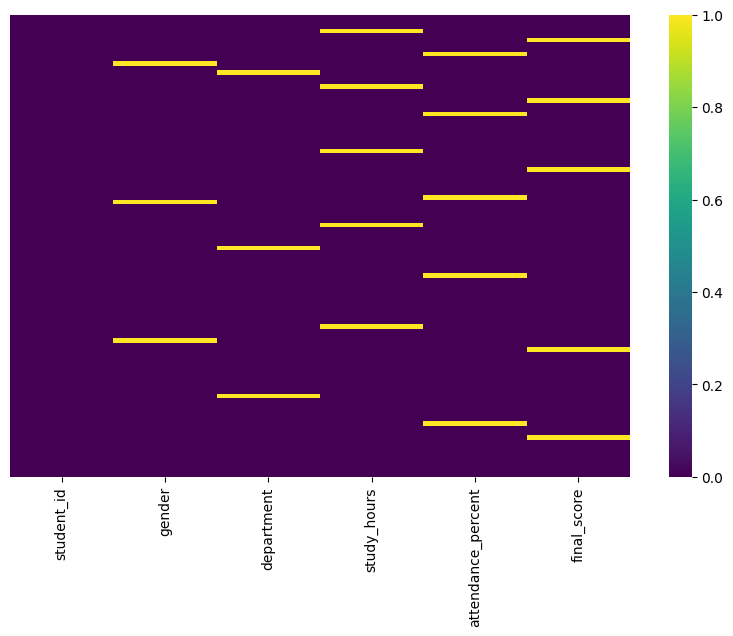

In [25]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna() , yticklabels=False , cbar=True , cmap='viridis')
plt.show()

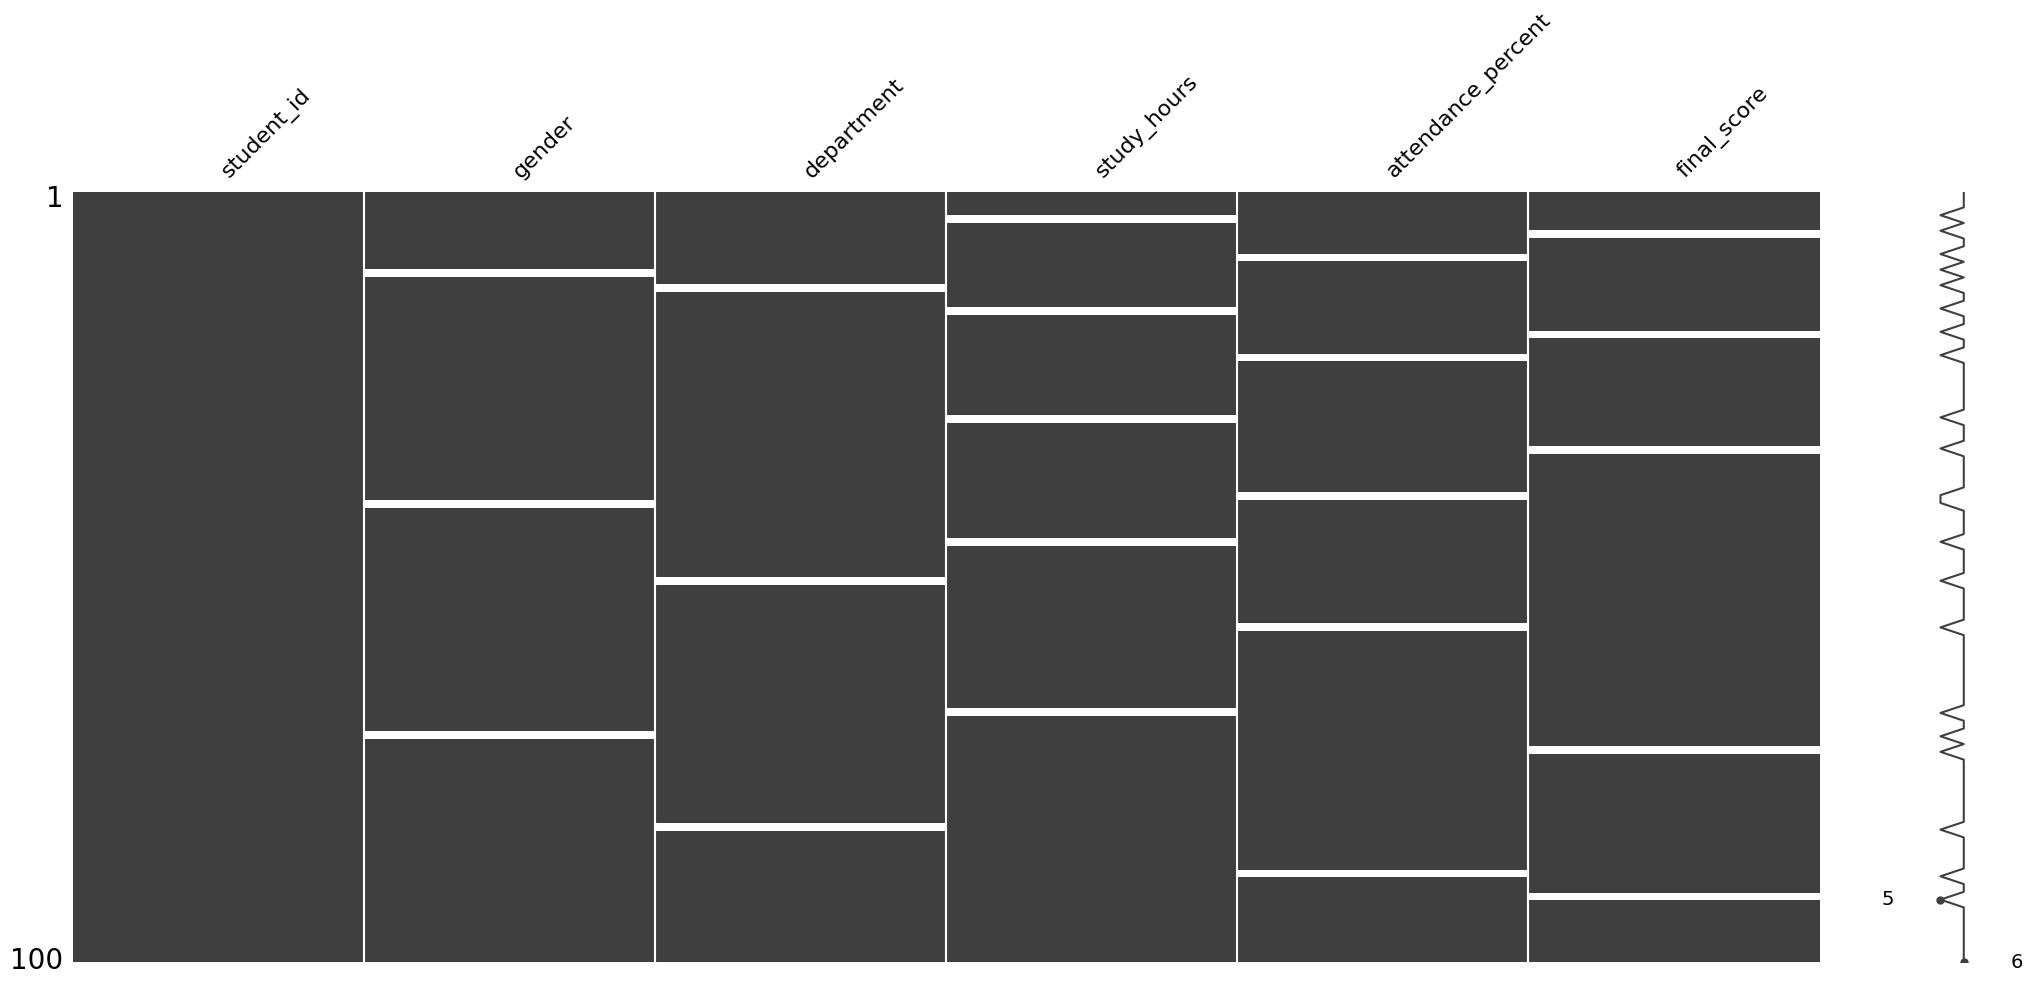

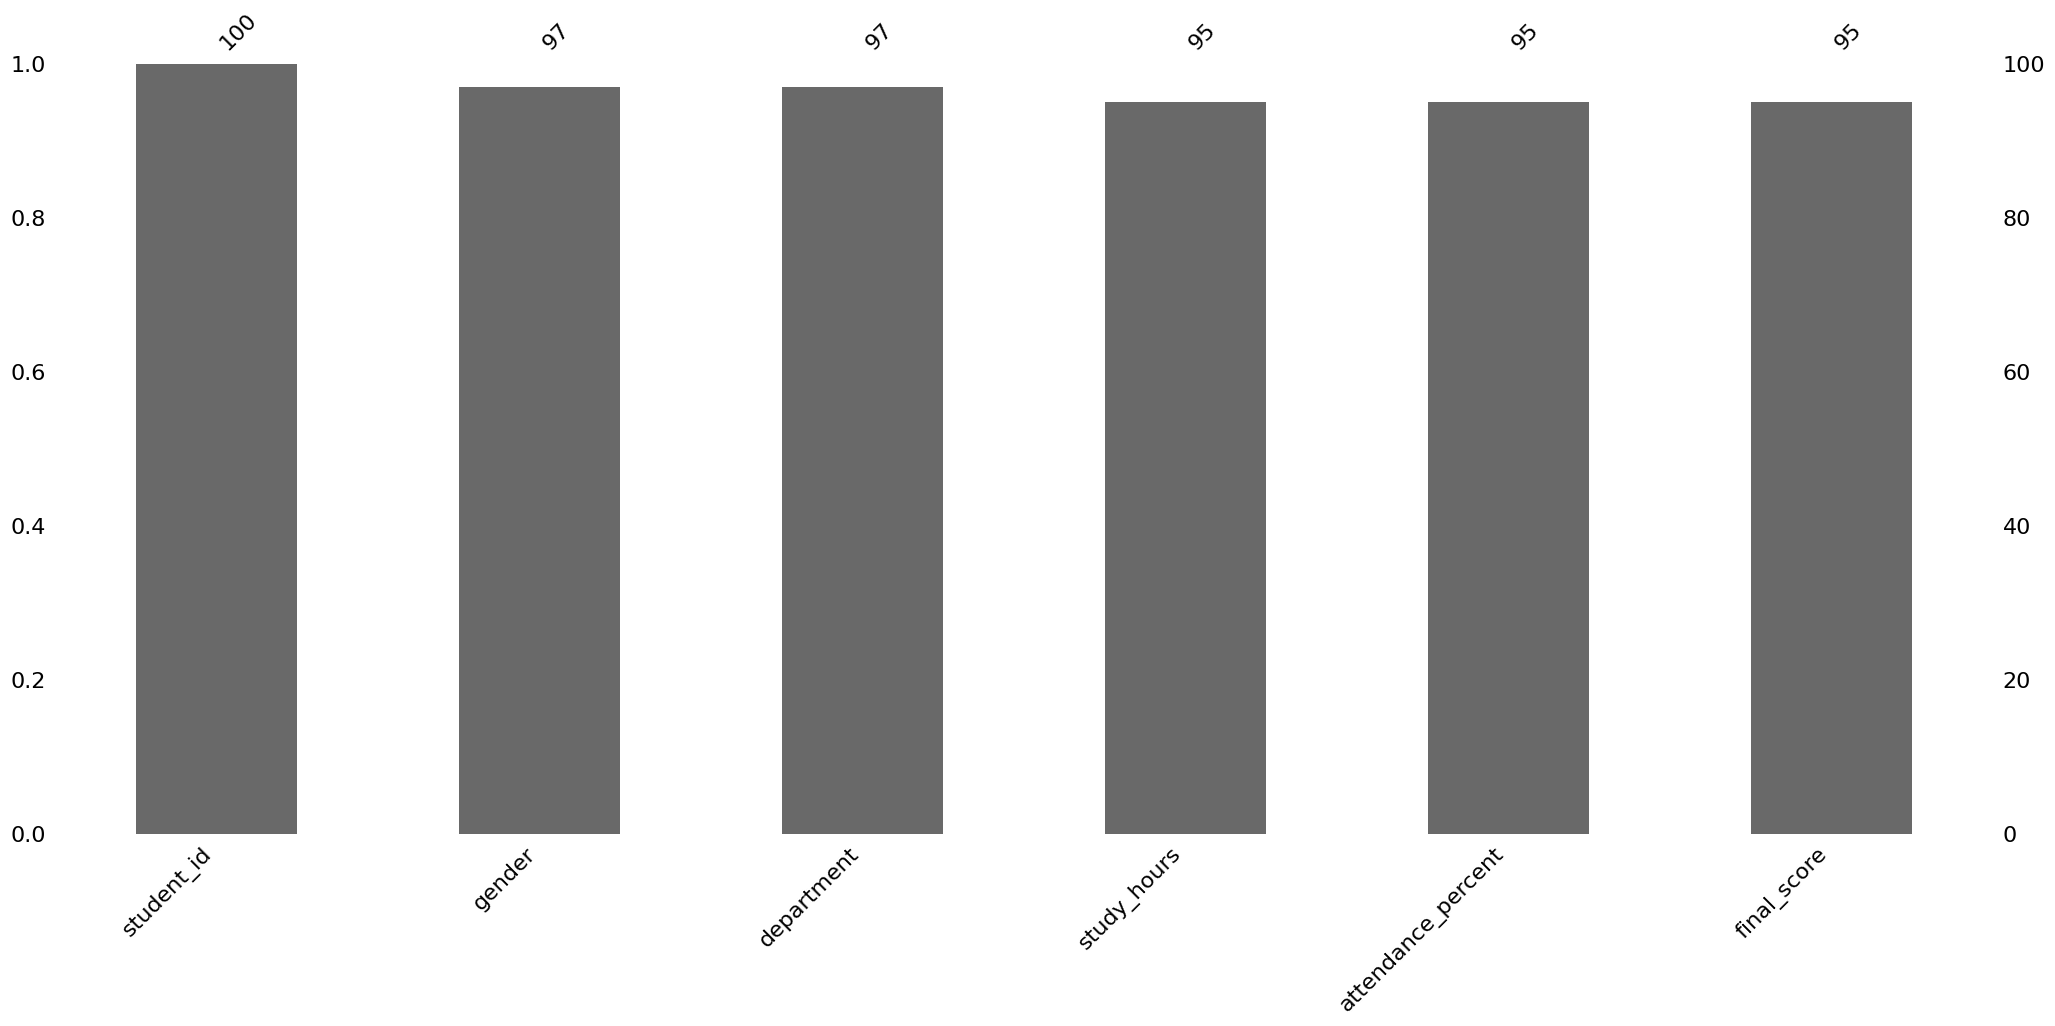

In [27]:
import missingno as msno
msno.matrix(df)
plt.show()
msno.bar(df)
plt.show()